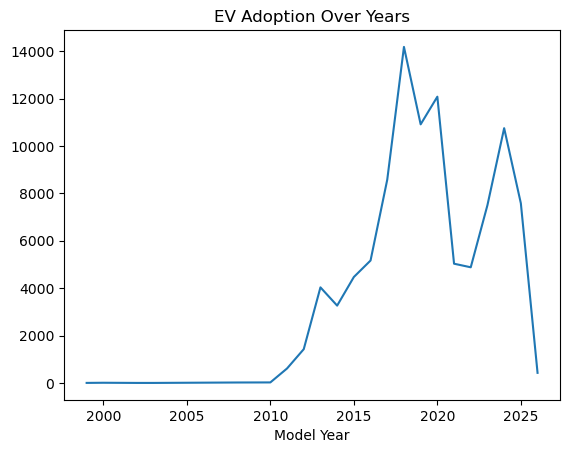

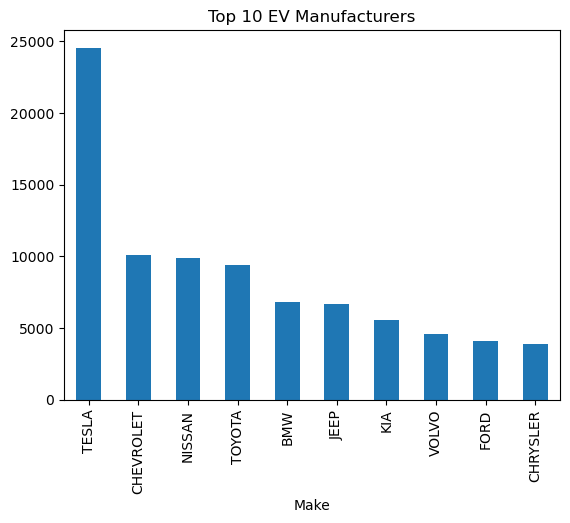

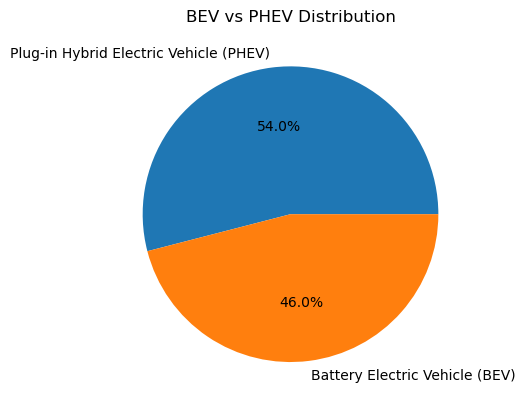

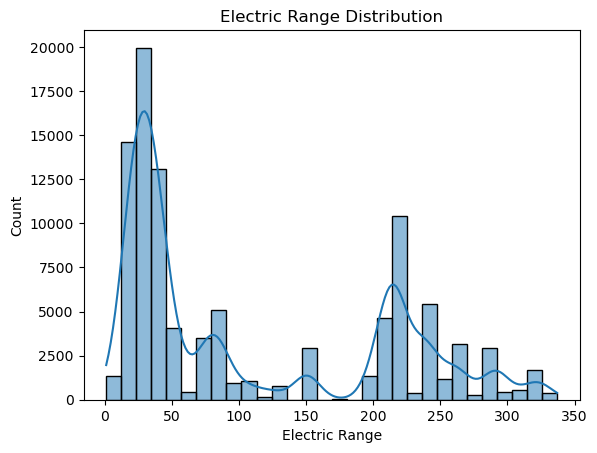

Logistic Regression Report

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      9252
           1       0.99      0.98      0.99     10935

    accuracy                           0.99     20187
   macro avg       0.98      0.99      0.99     20187
weighted avg       0.99      0.99      0.99     20187



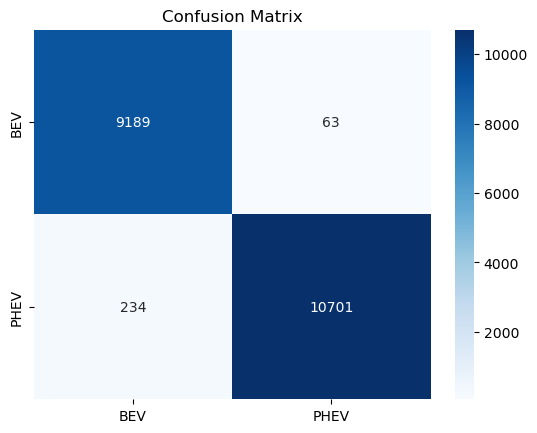

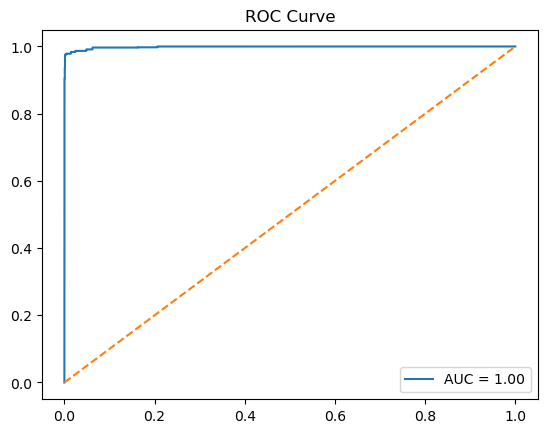

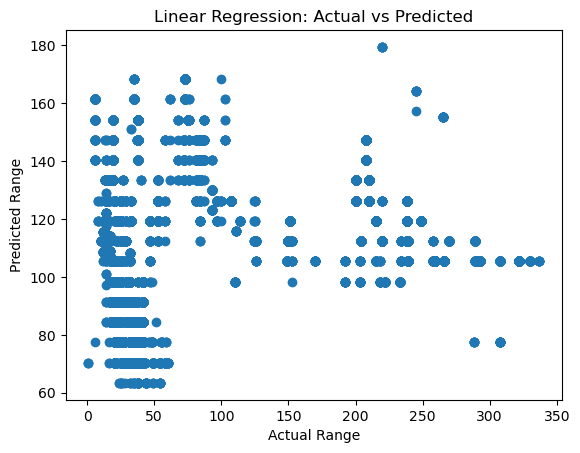

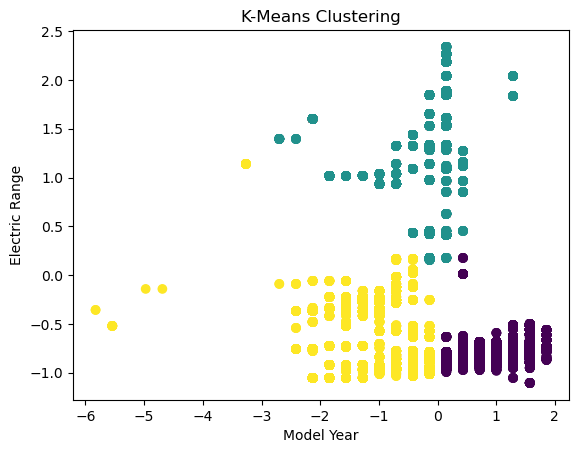

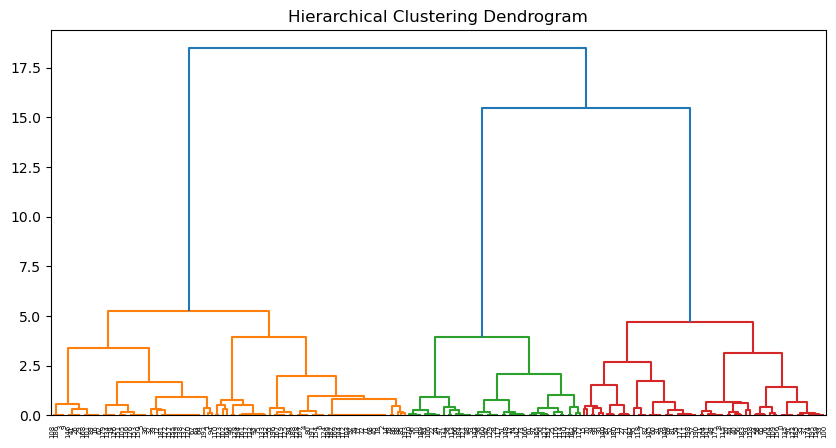

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_auc_score, roc_curve
from scipy.cluster.hierarchy import dendrogram, linkage

df = pd.read_csv("Electric_Vehicle_Population_Data.csv")

df = df.dropna(subset=["Electric Range", "Model Year", "Electric Vehicle Type"])
df = df[df["Electric Range"] > 0]

# ---------------- EDA ----------------

plt.figure()
df["Model Year"].value_counts().sort_index().plot(kind="line")
plt.title("EV Adoption Over Years")
plt.show()

plt.figure()
df["Make"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 EV Manufacturers")
plt.show()

plt.figure()
df["Electric Vehicle Type"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("BEV vs PHEV Distribution")
plt.ylabel("")
plt.show()

plt.figure()
sns.histplot(df["Electric Range"], bins=30, kde=True)
plt.title("Electric Range Distribution")
plt.show()

# ---------------- SUPERVISED LEARNING 1 ----------------
# Logistic Regression (Classification)

ml_df = df[["Model Year", "Electric Range", "Base MSRP", "Electric Vehicle Type"]].dropna()

le = LabelEncoder()
ml_df["Electric Vehicle Type"] = le.fit_transform(ml_df["Electric Vehicle Type"])

X = ml_df.drop("Electric Vehicle Type", axis=1)
y = ml_df["Electric Vehicle Type"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

log_model = LogisticRegression()
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:, 1]

print("Logistic Regression Report\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["BEV", "PHEV"],
            yticklabels=["BEV", "PHEV"])
plt.title("Confusion Matrix")
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.legend()
plt.title("ROC Curve")
plt.show()

# ---------------- SUPERVISED LEARNING 2 ----------------
# Linear Regression (Prediction)

X_lr = df[["Model Year", "Base MSRP"]].dropna()
y_lr = df.loc[X_lr.index, "Electric Range"]

X_train, X_test, y_train, y_test = train_test_split(
    X_lr, y_lr, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

y_pred = lin_model.predict(X_test)

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Range")
plt.ylabel("Predicted Range")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

# ---------------- UNSUPERVISED LEARNING 1 ----------------
# K-Means Clustering

cluster_data = df[["Model Year", "Electric Range"]].dropna()
cluster_scaled = StandardScaler().fit_transform(cluster_data)

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(cluster_scaled)

plt.figure()
plt.scatter(cluster_scaled[:, 0], cluster_scaled[:, 1], c=clusters)
plt.title("K-Means Clustering")
plt.xlabel("Model Year")
plt.ylabel("Electric Range")
plt.show()

# ---------------- UNSUPERVISED LEARNING 2 ----------------
# Hierarchical Clustering

linked = linkage(cluster_scaled[:200], method="ward")

plt.figure(figsize=(10, 5))
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.show()
